# CreditPilot — Exploratory Data Analysis (EDA)

## Overview
This notebook performs Exploratory Data Analysis (EDA) on the financial dataset generated for the CreditPilot system. The goal is to understand the structure, distribution, and relationships between variables that influence loan default risk.

---

## Objectives

- Understand dataset structure and feature distributions  
- Identify patterns in **loan defaults vs non-defaults**  
- Analyze relationships between financial and behavioral variables  
- Detect correlations and key risk-driving features  
- Prepare insights for feature engineering and model building  

---

## Key Areas of Analysis

### Univariate Analysis
- Distribution of income, loan amount, credit score  
- Distribution of target variable (`loan_status`)  

### Bivariate Analysis
- Loan status vs credit score  
- Loan status vs DTI  
- Loan status vs EMI burden  

### Correlation Analysis
- Heatmap of numerical features  
- Identify strongest predictors of default  

---

## Expected Outcomes

- Identify **high-risk customer patterns**  
- Understand **important features for ML model**  
- Validate realism of synthetic dataset  
- Generate insights for **risk modeling**  

---

## Next Step

 Feature Engineering & Data Preprocessing for ML model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("../data/raw/creditpilot_dataset.csv")
df.head()

,user_id,age,employment_type,employment_length_years,annual_income,income_stability_score,loan_amount,loan_term_months,interest_rate,loan_type,...,emi_to_income_ratio,loan_to_income_ratio,num_credit_inquiries,late_payment_count,default_history,repayment_history_score,credit_history_length_years,job_stability_score,spending_to_income_ratio,loan_status
0,1,59,salaried,18,200000.000000,85.0,175387.433746,60,8.198239,education,...,0.214373,0.876937,3,0,0,82.310176,22,90.0,0.675222,0
1,2,49,self-employed,3,289124.248220,27.5,194435.024170,48,9.811462,personal,...,0.203945,0.672496,2,3,0,38.582487,4,15.0,0.290793,0
2,3,35,salaried,3,200000.000000,47.5,122620.314192,36,9.658658,education,...,0.236219,0.613102,6,6,1,24.476369,3,15.0,0.635074,1
3,4,28,unemployed,0,200000.000000,20.0,249992.823707,36,11.239523,auto,...,0.492770,1.249964,1,0,0,89.003286,1,10.0,0.472154,1
4,5,41,salaried,2,253596.809558,45.0,309077.838184,60,12.904879,auto,...,0.332059,1.218777,1,0,0,74.314983,4,10.0,0.664146,1


## Basic Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      10000 non-null  int64  
 1   age                          10000 non-null  int64  
 2   employment_type              10000 non-null  object 
 3   employment_length_years      10000 non-null  int64  
 4   annual_income                10000 non-null  float64
 5   income_stability_score       10000 non-null  float64
 6   loan_amount                  10000 non-null  float64
 7   loan_term_months             10000 non-null  int64  
 8   interest_rate                10000 non-null  float64
 9   loan_type                    10000 non-null  object 
 10  emi                          10000 non-null  float64
 11  total_existing_loans         10000 non-null  int64  
 12  total_debt                   10000 non-null  float64
 13  debt_to_income_ra

In [6]:
df.describe()

,user_id,age,employment_length_years,annual_income,income_stability_score,loan_amount,loan_term_months,interest_rate,emi,total_existing_loans,...,emi_to_income_ratio,loan_to_income_ratio,num_credit_inquiries,late_payment_count,default_history,repayment_history_score,credit_history_length_years,job_stability_score,spending_to_income_ratio,loan_status
count,10000.00000,10000.000000,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,40.062600,8.588400,2.607277e+05,53.559000,3.423246e+05,74.647200,10.511546,6964.894341,1.986100,...,0.320876,1.309115,3.034900,1.519300,0.064700,70.528310,10.621100,44.53450,0.501461,0.574900
std,2886.89568,11.179087,6.105482,1.347093e+05,19.565098,4.562807e+05,74.953461,1.529207,5826.786456,1.394741,...,0.189803,1.436916,1.739881,1.217939,0.246008,14.469846,6.220772,28.45236,0.148762,0.494383
min,1.00000,21.000000,0.000000,2.000000e+05,20.000000,4.012326e+04,12.000000,8.000523,948.234409,0.000000,...,0.056894,0.200028,0.000000,0.000000,0.000000,20.000000,1.000000,10.00000,0.100000,0.000000
25%,2500.75000,31.000000,3.000000,2.000000e+05,40.000000,1.104326e+05,36.000000,9.237293,3373.896105,1.000000,...,0.177278,0.491582,2.000000,1.000000,0.000000,61.697016,5.000000,15.00000,0.400076,0.000000
50%,5000.50000,40.000000,8.000000,2.000000e+05,55.000000,1.654724e+05,48.000000,10.451720,5368.273302,2.000000,...,0.270565,0.707402,3.000000,1.000000,0.000000,71.844545,11.000000,40.00000,0.503329,1.000000
75%,7500.25000,50.000000,14.000000,2.612163e+05,67.500000,3.392466e+05,84.000000,11.595831,8724.120779,3.000000,...,0.417727,1.220682,4.000000,2.000000,0.000000,81.392268,16.000000,70.00000,0.602495,1.000000
max,10000.00000,59.000000,19.000000,2.156802e+06,87.500000,8.435910e+06,300.000000,13.999246,102573.772913,12.000000,...,1.060204,5.997390,11.000000,7.000000,1.000000,97.500000,23.000000,95.00000,0.900000,1.000000


In [7]:
df.isnull().sum()

user_id                        0
age                            0
employment_type                0
employment_length_years        0
annual_income                  0
income_stability_score         0
loan_amount                    0
loan_term_months               0
interest_rate                  0
loan_type                      0
emi                            0
total_existing_loans           0
total_debt                     0
debt_to_income_ratio           0
credit_score                   0
credit_utilization_ratio       0
emi_to_income_ratio            0
loan_to_income_ratio           0
num_credit_inquiries           0
late_payment_count             0
default_history                0
repayment_history_score        0
credit_history_length_years    0
job_stability_score            0
spending_to_income_ratio       0
loan_status                    0
dtype: int64

## Target Distribution

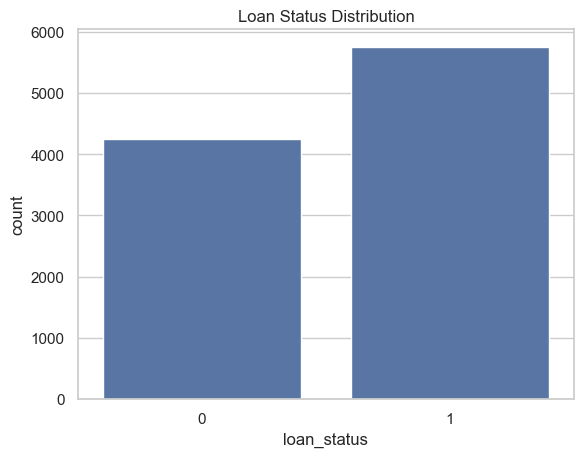

In [8]:
df["loan_status"].value_counts()

sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

## Income Distribution

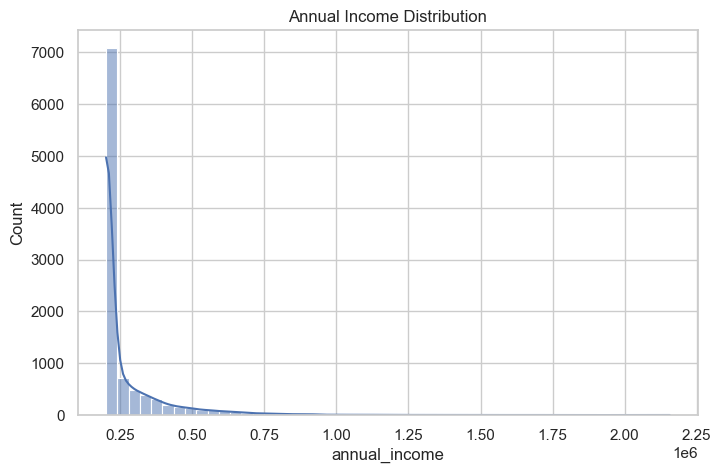

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["annual_income"], bins=50, kde=True)
plt.title("Annual Income Distribution")
plt.show()

## Credit Score vs Default

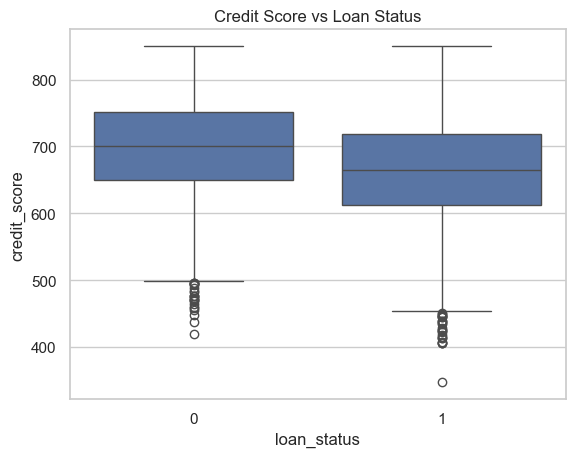

In [12]:
sns.boxplot(x="loan_status", y="credit_score", data=df)
plt.title("Credit Score vs Loan Status")
plt.show()

## DTI Analysis

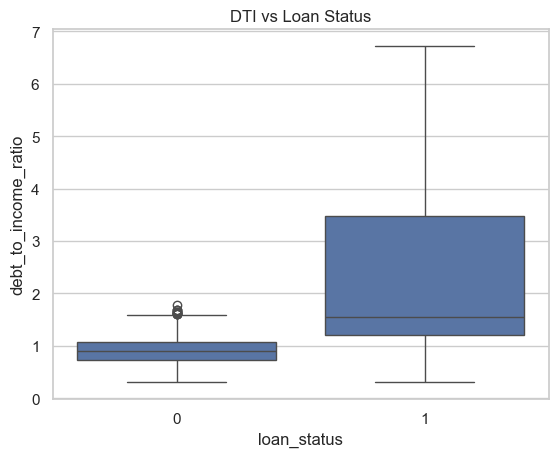

In [13]:
sns.boxplot(x="loan_status", y="debt_to_income_ratio", data=df)
plt.title("DTI vs Loan Status")
plt.show()

## EMI Burden Analysis

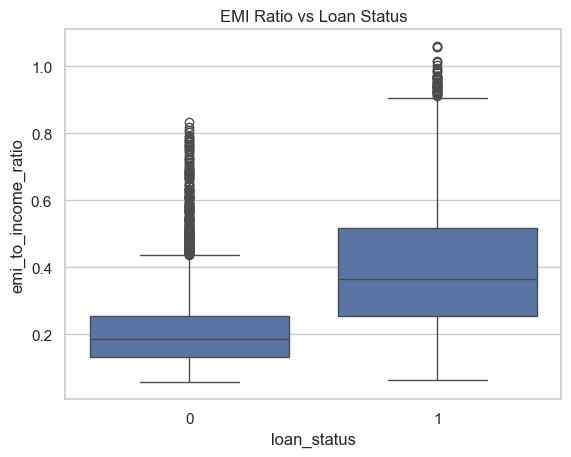

In [14]:
sns.boxplot(x="loan_status", y="emi_to_income_ratio", data=df)
plt.title("EMI Ratio vs Loan Status")
plt.show()

## Correlation Heatmap

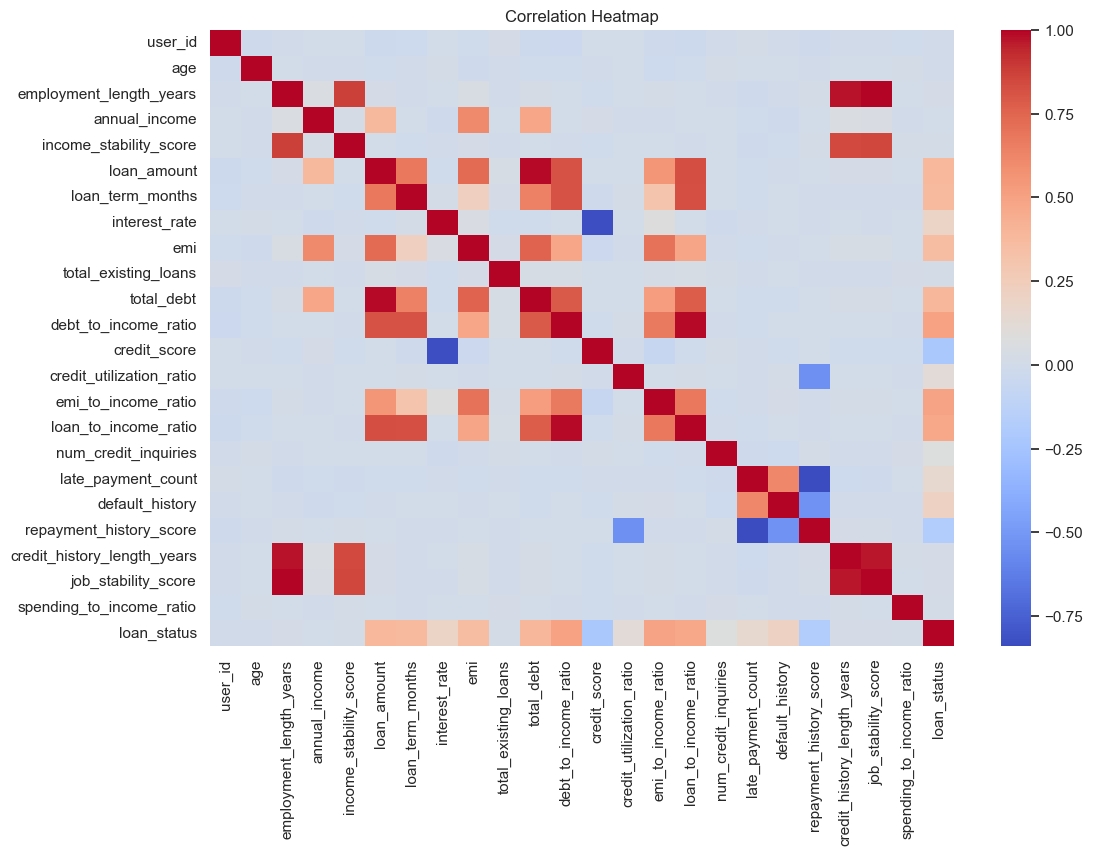

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Key Insights

- Lower credit scores are strongly associated with higher default risk  
- Higher DTI and EMI ratios increase probability of default  
- Behavioral factors like late payments also contribute significantly  
- Income alone is not a strong predictor without considering debt  
